# Exploration des données (EDA) – Projet fraude pré-sinistre

## 1. Contexte et objectif
Objectif : analyser un jeu de données d'assurance 
et préparer une modélisation visant à prédire la fraude (fraud_reported).

Cette étape couvre :
- la volumétrie,
- la qualité des données,
- les biais et limites,
- les relations entre variables,
- 5 visualisations avec validations statistiques.

## 2. Source des données
Le dataset **insurance_claims.csv** provient de **Mendeley Data** (ABDELRAHIM AQQAD), publié le **22 août 2023** (Version 2), DOI : **10.17632/992mh7dk9y.2**.
Licence : **CC BY 4.0** (réutilisation autorisée avec attribution).

## 3. Chargement et aperçu du jeu de données

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("../data/insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 4. Volumétrie et structure des données

In [33]:
df.shape

(1000, 40)

Le jeu de données contient **1000 observations** et **40 variables**.
Chaque ligne représente un sinistre. 
Il s’agit d’un dataset de taille modérée, suffisant pour une analyse exploratoire
et des modèles de machine learning classiques.

In [34]:
df.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 '_c39']

Les variables peuvent être regroupées en familles décrivant :
- le contrat d’assurance (prime, franchise, garanties),
- le profil de l’assuré (âge, sexe, profession, niveau d’éducation),
- le contexte du sinistre (date, type, sévérité, dommages)
- les montants déclarés.
Cette structuration facilite l’analyse métier et permet d’identifier
les dimensions potentiellement discriminantes dans la détection de fraude.

La variable cible est **fraud_reported** (binaire), indiquant si un sinistre a été jugé **frauduleux** ou **non frauduleux** après examens (manuels + automatisés).

Particularités / limites :
- Données **anonymisées** : impossible d’identifier les individus (ok pour la confidentialité, mais limite les possibilités d’enrichissement externe via croisement avec d’autres bases clients ou contextuelles,
ce qui restreint certaines analyses avancées réalisables en contexte industriels).
- Risque potentiel de **fuite d’information** : certaines variables pourraient refléter des éléments connus après investigation (à vérifier). Les variables renseignées après investigation doivent être exclues de la modélisation. Cela fausse le modèle. 
- Variable `_c39` non documentée : à investiguer (colonne technique issue de l’export?) et potentiellement supprimer.
- Les variables `insured_*` décrivent le profil socio-démographique de l’assuré.
Elles peuvent introduire des biais statistiques ou éthiques et devront être
utilisées avec prudence, voire exclues, lors de la modélisation.

| Famille de variables | Exemples | Rôle | Pertinence pour la fraude |
|---------------------|----------|------|---------------------------|
| Contrat (policy_*) | policy_annual_premium, deductible | Décrit le contrat | Élevée |
| Assuré (insured_*) | age, occupation | Profil client | Moyenne (biais) |
| Sinistre (incident_*) | type, severity | Contexte du sinistre | Élevée |
| Montants (claim_*) | total_claim_amount | Impact financier | Très élevée |
| Administratif | police_report_available | Processus | Risque de fuite |

In [35]:
df.dtypes.value_counts()

object     21
int64      17
float64     2
Name: count, dtype: int64

On observe :
- **21 variables catégorielles** (`object`) : variables qualitatives décrivant des catégories (ex. type de sinistre, état, profession),
- **17 variables numériques discrètes** (`int64`) : variables entières (ex. âge, nombre de véhicules, nombre de témoins),
- **2 variables numériques continues** (`float64`) : variables quantitatives continues (ex. montants financiers).

- les **variables catégorielles** devront être transformées en valeurs numériques à l’aide d’un **encodage** (par exemple *one-hot encoding* ou encodage ordinal), afin d’être exploitables par les modèles de machine learning ;
- certaines **variables numériques à forte cardinalité** (beaucoup de valeurs différentes, comme des identifiants) devront être analysées avec précaution, car elles peuvent introduire du bruit ou du sur-apprentissage ;
- le jeu de données se prête particulièrement à l’utilisation de **modèles capables de gérer des données mixtes**, tels que les arbres de décision, les forêts aléatoires ou les méthodes de boosting.

## 5. Variable cible et déséquilibre des classes

In [36]:
df["fraud_reported"].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

La variable cible `fraud_reported` indique si un sinistre a été jugé **frauduleux (Y)** ou **non frauduleux (N)** après analyse.

La répartition observée est la suivante :
- **N (non frauduleux)** : 753 sinistres  
- **Y (frauduleux)** : 247 sinistres  

In [37]:
df["fraud_reported"].value_counts(normalize=True, dropna=False)

fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64

En proportion, cela représente environ 75 % de non-fraude contre 25 % de fraude.

### Interprétation simple 

- **Proche de 50 / 50**  
  → équilibré.

- **70–80 / 20–30**  
  → déséquilibre modéré.

- **95 / 5 ou 99 / 1**  
  → déséquilibre fort.

Dans notre cas, il s'agit d'un déséquilibre de classes modéré à prendre en compte
lors de la modélisation.

## 6. Qualité des données et premières corrections

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

- La majorité des variables sont **complètement renseignées** (1000 valeurs non nulles).
- Une variable présente des **valeurs manquantes** :
  - `authorities_contacted` : 999 valeurs non nulles → **1 valeur manquante** à traiter lors du pré-processing.
- La colonne `_c39` contient **0 valeur non nulle** : elle est vide et devra être **supprimée**.

Globalement, la qualité des données est **bonne**, avec peu de valeurs manquantes, ce qui est favorable pour la suite du projet.

In [39]:
df.duplicated().sum()

np.int64(0)

La vérification des doublons à l’aide de la méthode `df.duplicated().sum()` ne met en évidence **aucune ligne dupliquée** dans le jeu de données.

Cela signifie que chaque observation correspond à un sinistre unique.  
Aucune action de suppression ou de correction liée aux doublons n’est donc nécessaire à ce stade de l’analyse.

Le nettoyage complet des données sera réalisé **après l’analyse exploratoire** et **avant la modélisation**, afin de :
- conserver une EDA fidèle aux données brutes,
- justifier les choix de traitement (valeurs manquantes, variables inutiles, outliers),
- garantir un pré-traitement reproductible (pipeline).

À ce stade de l’EDA, seules des corrections “sans risque” peuvent être appliquées
(ex. suppression d’une colonne entièrement vide comme `_c39`, conversion des dates),
tandis que le traitement des outliers et des encodages sera défini après les analyses graphiques.

In [40]:
df = df.drop(columns=["_c39"])

In [41]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')

In [42]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"], errors="coerce")
df["incident_date"] = pd.to_datetime(df["incident_date"], errors="coerce")

In [43]:
df[["policy_bind_date", "incident_date"]].dtypes

policy_bind_date    datetime64[ns]
incident_date       datetime64[ns]
dtype: object

In [44]:
df.isna().sum().sort_values(ascending=False).head(10)

authorities_contacted          91
witnesses                       0
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
months_as_customer              0
dtype: int64

Les variables `policy_bind_date` et `incident_date` ont été converties au format `datetime64[ns]` afin de permettre des analyses temporelles ultérieures (durées, saisons, évolution dans le temps).

La conversion s’est effectuée sans générer de valeurs manquantes supplémentaires.

## 7. Analyse descriptive des variables numériques

In [45]:
desc_num = df.select_dtypes(include="number").describe().T
desc_num.sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
total_claim_amount,1000.0,5.276194e+04,2.640153e+04,100.00,41812.5000,58055.0,70592.500,114920.00
vehicle_claim,1000.0,3.792895e+04,1.888625e+04,70.00,30292.5000,42100.0,50822.500,79560.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
injury_claim,1000.0,7.433420e+03,4.880952e+03,0.00,4295.0000,6775.0,11305.000,21450.00
property_claim,1000.0,7.399570e+03,4.824726e+03,0.00,4445.0000,6750.0,10885.000,23670.00
auto_year,1000.0,2.005103e+03,6.015861e+00,1995.00,2000.0000,2005.0,2010.000,2015.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59


In [46]:
# Sélection uniquement des variables numériques
desc_num = df.select_dtypes(include="number").describe().T

# Calcul du ratio max / 75% pour détecter les valeurs extrêmes
desc_num["ratio_max_q75"] = desc_num["max"] / desc_num["75%"]

# Tri des variables les plus sujettes aux outliers
desc_num.sort_values("ratio_max_q75", ascending=False).head(10)

,count,mean,std,min,25%,50%,75%,max,ratio_max_q75
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00,inf
property_claim,1000.0,7.399570e+03,4.824726e+03,0.00,4445.0000,6750.0,10885.000,23670.00,2.174552
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00,1.969623
injury_claim,1000.0,7.433420e+03,4.880952e+03,0.00,4295.0000,6775.0,11305.000,21450.00,1.897391
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00,1.733937
total_claim_amount,1000.0,5.276194e+04,2.640153e+04,100.00,41812.5000,58055.0,70592.500,114920.00,1.627935
vehicle_claim,1000.0,3.792895e+04,1.888625e+04,70.00,30292.5000,42100.0,50822.500,79560.00,1.565448
witnesses,1000.0,1.487000e+00,1.111335e+00,0.00,1.0000,1.0,2.000,3.00,1.500000
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00,1.454545
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59,1.446350


Le tableau `df.describe().T` fournit des statistiques descriptives pour chaque variable numérique.  
Afin de le rendre exploitable dans une démarche d’EDA, on procède à une analyse ciblée.

### Méthode utilisée

1. **Identifier les variables les plus importantes en termes d’ordre de grandeur**  
   → tri des variables par moyenne (`mean`) décroissante.  
   Cela permet de repérer les variables financières ou quantitatives dominantes.

2. **Évaluer la dispersion et la présence potentielle d’outliers**  
   → comparaison entre la valeur maximale (`max`) et le troisième quartile (`75%`) à l’aide du ratio :

   `ratio_max_q75 = max / 75%`

### Interprétation simple du ratio `max / 75%`

- **Ratio proche de 1**  
  → distribution stable, peu ou pas de valeurs extrêmes.

- **Ratio > 1.5**  
  → présence probable d’outliers (quelques valeurs très élevées).

- **Ratio très élevé ou infini**  
  → valeur aberrante, distribution très asymétrique ou variable nécessitant une attention particulière
  (transformation, plafonnement, ou exclusion éventuelle).

### Variables particulièrement utiles à commenter avant la modélisation

Certaines variables ressortent à la fois :
- par leur **niveau moyen élevé**,
- par leur **forte dispersion**,
- et par leur **importance métier** dans un contexte de fraude à l’assurance.

Il s’agit notamment de :
- `total_claim_amount`
- `vehicle_claim`
- `property_claim`
- `injury_claim`
- `umbrella_limit`

Ces variables :
- portent des **montants financiers significatifs**,
- présentent souvent des **distributions asymétriques**,
- peuvent fortement **influencer l’apprentissage des modèles**.

Elles devront faire l’objet de traitements spécifiques lors de la phase de préparation des données
(log-transformations, gestion des valeurs extrêmes, normalisation éventuelle).

## 8. Repérage des variables qualitatives

Le jeu de données contient un nombre important de variables qualitatives (catégorielles), notamment :

- des variables liées au **contrat** (`policy_state`, `policy_csl`),
- au **profil de l’assuré** (`insured_sex`, `insured_education_level`, `insured_occupation`, `insured_hobbies`),
- au **contexte du sinistre** (`incident_type`, `collision_type`, `incident_severity`),
- au **processus administratif** (`authorities_contacted`, `police_report_available`).

Ces variables :
- ne nécessitent pas de statistiques descriptives numériques,
- seront principalement analysées **via des visualisations** (répartition des modalités, comparaison avec la variable cible),
- pourront présenter des enjeux de **biais** ou de **fuite d’information**, qui seront discutés lors de l’interprétation.

L’analyse détaillée de ces variables sera donc réalisée dans la section de visualisation exploratoire.

## 9. Conclusion de l’EDA tabulaire

L’analyse exploratoire initiale a permis de :

- vérifier la structure globale du jeu de données,
- identifier et traiter les éventuels problèmes de qualité (colonne vide, types de données),
- analyser la distribution des variables numériques et repérer la présence potentielle de valeurs extrêmes,
- confirmer la variable cible (`fraud_reported`) et son déséquilibre modéré,
- repérer les principales variables quantitatives et qualitatives d’intérêt métier.

Le jeu de données apparaît globalement cohérent et exploitable pour la suite de l’analyse.
Aucune anomalie bloquante n’a été identifiée à ce stade.

## 10. Visualisation exploratoire des données

### Transition vers la visualisation exploratoire

Les analyses réalisées jusqu’à présent reposent essentiellement sur des statistiques descriptives tabulaires.
Si celles-ci permettent une première compréhension des données, elles restent limitées pour :

- analyser finement les distributions,
- comparer les variables explicatives à la variable cible,
- détecter visuellement les asymétries, regroupements ou comportements atypiques,
- explorer les relations entre variables, notamment dans un contexte de fraude.

La prochaine étape consiste donc à réaliser une **visualisation exploratoire des données**, en particulier :

- l’étude graphique des variables numériques clés (distributions, outliers),
- l’analyse des variables qualitatives (répartition des modalités),
- la comparaison systématique des variables avec la variable cible `fraud_reported`.

Ces visualisations permettront d’approfondir l’interprétation métier et de préparer les choix méthodologiques pour la phase de modélisation.

### Choix des outils de visualisation

Les visualisations exploratoires présentées ci-dessous sont réalisées principalement avec la bibliothèque Seaborn, choisie pour sa lisibilité et son adéquation aux analyses statistiques en phase d’EDA.  
Matplotlib est utilisé en complément pour certains ajustements graphiques.

### Graphique 1 – Distribution du montant total du sinistre selon la fraude

**Objectif :**  
Analyser la relation entre le montant total du sinistre (`total_claim_amount`) et la variable cible `fraud_reported`, afin d’identifier d’éventuelles différences de distribution entre les sinistres frauduleux et non frauduleux.

Le montant total du sinistre est une variable numérique continue.  
Un boxplot est particulièrement adapté pour comparer les distributions de cette variable selon une variable catégorielle binaire, car il permet de visualiser la médiane, la dispersion et la présence d’éventuels outliers.

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

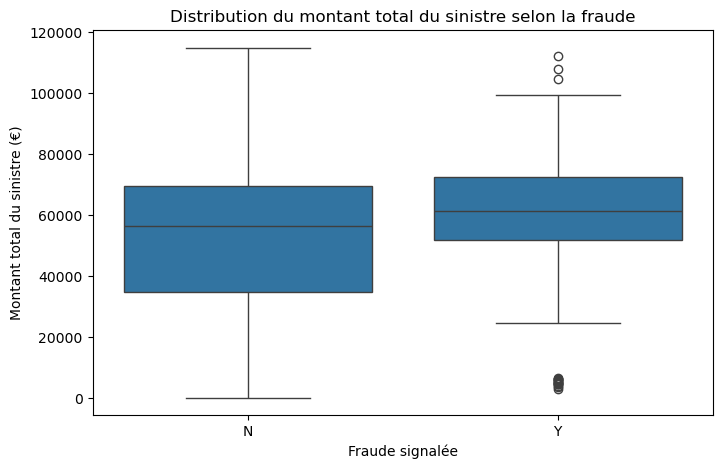

In [50]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="fraud_reported",
    y="total_claim_amount",
    data=df,
    order=["N", "Y"]
)

plt.title("Distribution du montant total du sinistre selon la fraude")
plt.xlabel("Fraude signalée")
plt.ylabel("Montant total du sinistre (€)")

plt.show()

**Lecture statistique :**  
Le boxplot compare la distribution de `total_claim_amount` entre les sinistres non frauduleux (N) et frauduleux (Y) à travers la médiane, les quartiles et la dispersion.  
La médiane des montants apparaît légèrement plus élevée pour les sinistres frauduleux, mais les distributions présentent un chevauchement important et des valeurs élevées dans les deux classes.

**Choix de représentation et adaptation :**  
Une première version du graphique incluait un nuage de points (stripplot) afin de visualiser la densité des observations.  
Cependant, la variable cible étant déséquilibrée (~75 % de non-fraude contre ~25 % de fraude), la classe `N` apparaissait mécaniquement plus dense, ce qui pouvait induire une lecture visuelle biaisée.  
Une représentation plus robuste (boxplot seul) a donc été retenue pour faciliter une comparaison objective entre les deux classes.

**Implications pour la suite :**  
Ces résultats indiquent que le montant total du sinistre constitue une variable informative mais faiblement discriminante lorsqu’elle est considérée isolément.  
Cela justifie l’exploration de variables complémentaires liées à la gravité du sinistre et au contexte déclaratif afin d’améliorer la capacité de détection de la fraude lors de la modélisation.